<a href="https://colab.research.google.com/github/sahasyy/ACM-Research-F25/blob/jagadeep-kalluri/implementation3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Bandwidth-Aware Federated Learning (PyTorch)

!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import random
import copy
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [14]:
# Reproducibility
torch.manual_seed(42)
random.seed(42)


In [15]:
# Define the model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


In [16]:
# Simulate bandwidth levels
bandwidth_levels = ["low", "medium", "high"]
drop_rates = {"low": 0.6, "medium": 0.3, "high": 0.1}
reliability_scores = {"low": 0.4, "medium": 0.7, "high": 0.9}

In [17]:
# Training functio
def train_local(model, dataloader, epochs=1):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for data, target in dataloader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    return model.state_dict()

In [18]:
# weighted aggregation
def aggregate_models(model_dicts, weights):
    global_model = copy.deepcopy(model_dicts[0])
    for key in global_model.keys():
        global_model[key] = sum([model_dicts[i][key] * weights[i] for i in range(len(model_dicts))])
    return global_model

In [19]:
#evaluation
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in dataloader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return correct / total


In [20]:
#prepare data
transform = transforms.ToTensor()
train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [21]:
#simulate 5 clients
clients = random_split(train_data, [12000, 12000, 12000, 12000, 12000])  # 5 clients x 12,000
client_bandwidth = {f"client_{i}": random.choice(bandwidth_levels) for i in range(5)}

In [22]:
#federated learning
global_model = SimpleCNN()
rounds = 5
accuracy_per_round = []

for r in range(rounds):
    print(f"\n--- Round {r+1} ---")
    local_models = []
    weights = []
    total_weight = 0

    for i, client_data in enumerate(clients):
        cid = f"client_{i}"
        bw = client_bandwidth[cid]
        if random.random() > drop_rates[bw]:
            loader = DataLoader(client_data, batch_size=32, shuffle=True)
            model = SimpleCNN()
            model.load_state_dict(global_model.state_dict())
            local_state = train_local(model, loader)

            reliability = reliability_scores[bw]
            weight = len(client_data) * reliability
            local_models.append(local_state)
            weights.append(weight)
            total_weight += weight
        else:
            print(f"{cid} dropped (bandwidth={bw})")

    if local_models:
        weights = [w / total_weight for w in weights]
        global_model.load_state_dict(aggregate_models(local_models, weights))

    acc = evaluate_model(global_model, test_loader)
    accuracy_per_round.append(acc)
    print(f"Accuracy after round {r+1}: {acc:.4f}")


--- Round 1 ---
client_1 dropped (bandwidth=low)
client_2 dropped (bandwidth=low)
Accuracy after round 1: 0.7904

--- Round 2 ---
client_1 dropped (bandwidth=low)
client_2 dropped (bandwidth=low)
Accuracy after round 2: 0.8527

--- Round 3 ---
Accuracy after round 3: 0.8767

--- Round 4 ---
Accuracy after round 4: 0.8877

--- Round 5 ---
client_1 dropped (bandwidth=low)
Accuracy after round 5: 0.8932


In [23]:
#save model
torch.save(global_model.state_dict(), "bandwidth_fl_model.pth")

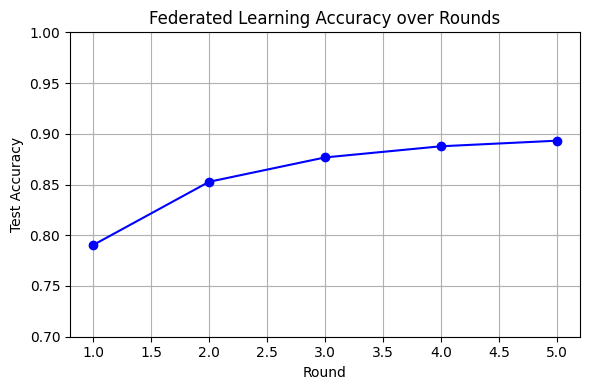

In [24]:
#plot accuracy
plt.figure(figsize=(6, 4))
plt.plot(range(1, rounds + 1), accuracy_per_round, marker='o', linestyle='-', color='blue')
plt.title("Federated Learning Accuracy over Rounds")
plt.xlabel("Round")
plt.ylabel("Test Accuracy")
plt.ylim(0.7, 1.0)
plt.grid(True)
plt.tight_layout()
plt.show()